In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D

In [5]:
dest = "Combined_RMSD_plot"

df_wt = pd.read_csv(os.path.join(dest, "RMSD_WT_per_ns.csv"))
df_bothace = pd.read_csv(os.path.join(dest, "RMSD_BothACE_per_ns.csv"))
df_238ace = pd.read_csv(os.path.join(dest, "RMSD_238ACE_per_ns.csv"))
df_238r = pd.read_csv(os.path.join(dest, "K238R_rmsd_per-ns.csv"))
df_412r = pd.read_csv(os.path.join(dest, "K412R_rmsd_per-ns.csv"))
df_412ace = pd.read_csv(os.path.join(dest, "RMSD_412ACE_per_ns.csv"))

In [51]:
figA = "figA-complex_structure.png"
figB = "figB-RMSD.png"
figC = "figC-RMSD-stdev.png"
figD = "figD-RMSF.png"
figE = "figE-pulling.png"
figF = "figF-pulling-peak.png"

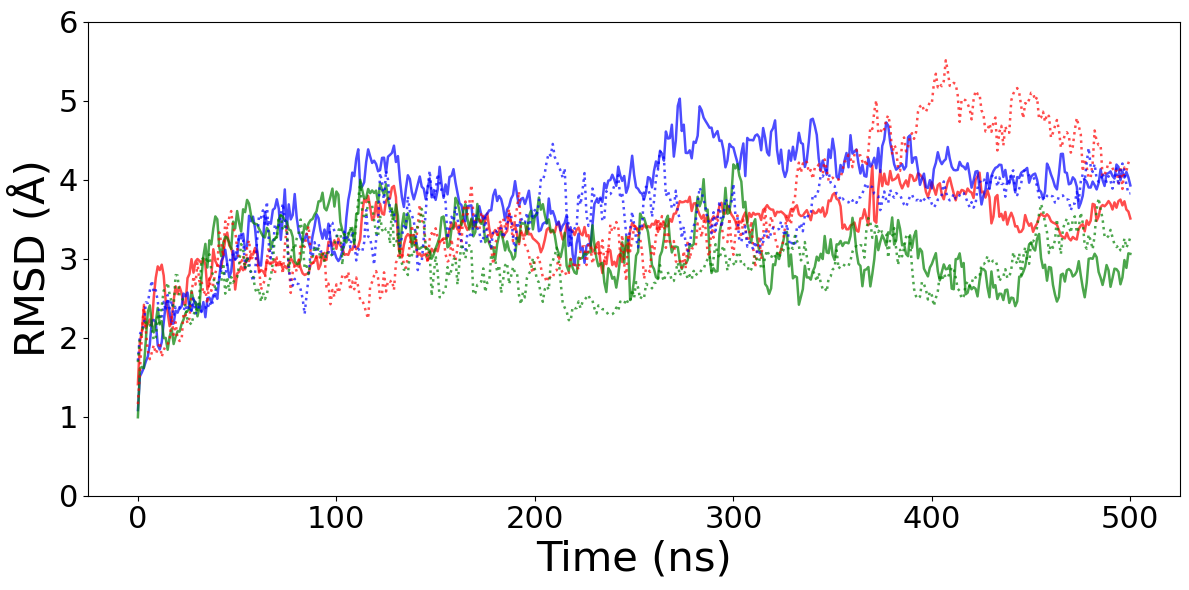

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(df_bothace["Time (ns)"], df_bothace["RMSD (Å)"],
         label="WT ac", color="red", linestyle="-", alpha=0.7, linewidth=1.8)

plt.plot(df_238ace["Time (ns)"], df_238ace["RMSD (Å)"],
         label="K238ac", color="blue", linestyle="-", alpha=0.7, linewidth=1.8)

plt.plot(df_412ace["Time (ns)"], df_412ace["RMSD (Å)"],
         label="K412ac", color="green", linestyle="-", alpha=0.7, linewidth=1.8)

plt.plot(df_wt["Time (ns)"], df_wt["RMSD (Å)"],
         label="WT", color="red", linestyle=":", alpha=0.7, linewidth=1.8)

plt.plot(df_238r["Time (ns)"], df_238r["RMSD (Å)"],
         label="K238R", color="blue", linestyle=":", alpha=0.7, linewidth=1.8)

plt.plot(df_412r["Time (ns)"], df_412r["RMSD (Å)"],
         label="K412R", color="green", linestyle=":", alpha=0.7, linewidth=1.8)

plt.xlabel("Time (ns)", fontsize=30)
plt.ylabel("RMSD (Å)", fontsize=30)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.ylim(0, 6)

#legend = plt.legend(loc="upper left", fontsize=14, frameon=False)

plt.tight_layout()

plt.savefig(figB, dpi=300, transparent=True)

plt.show()

In [105]:
var_order = ["WT Ac", "WT", "K238Ac", "K238R", "K412Ac", "K412R"]
avg_amp = {}
for n, d in enumerate([df_bothace, df_wt, df_238ace, df_238r, df_412ace, df_412r]):
    filtered_df = d[d["Time (ns)"] >= 100]
    stdev_rmsd = filtered_df["RMSD (Å)"].std()
    avg_amp[var_order[n]] = stdev_rmsd
    print("%s\t%f"%(var_order[n], stdev_rmsd))

df_avg_amp = pd.DataFrame(list(avg_amp.items()), columns=["Variant", "AvgAmplitude_per_ns"])

WT Ac	0.261737
WT	0.785652
K238Ac	0.368836
K238R	0.311616
K412Ac	0.364394
K412R	0.333643


/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/3670881282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_avg_amp,


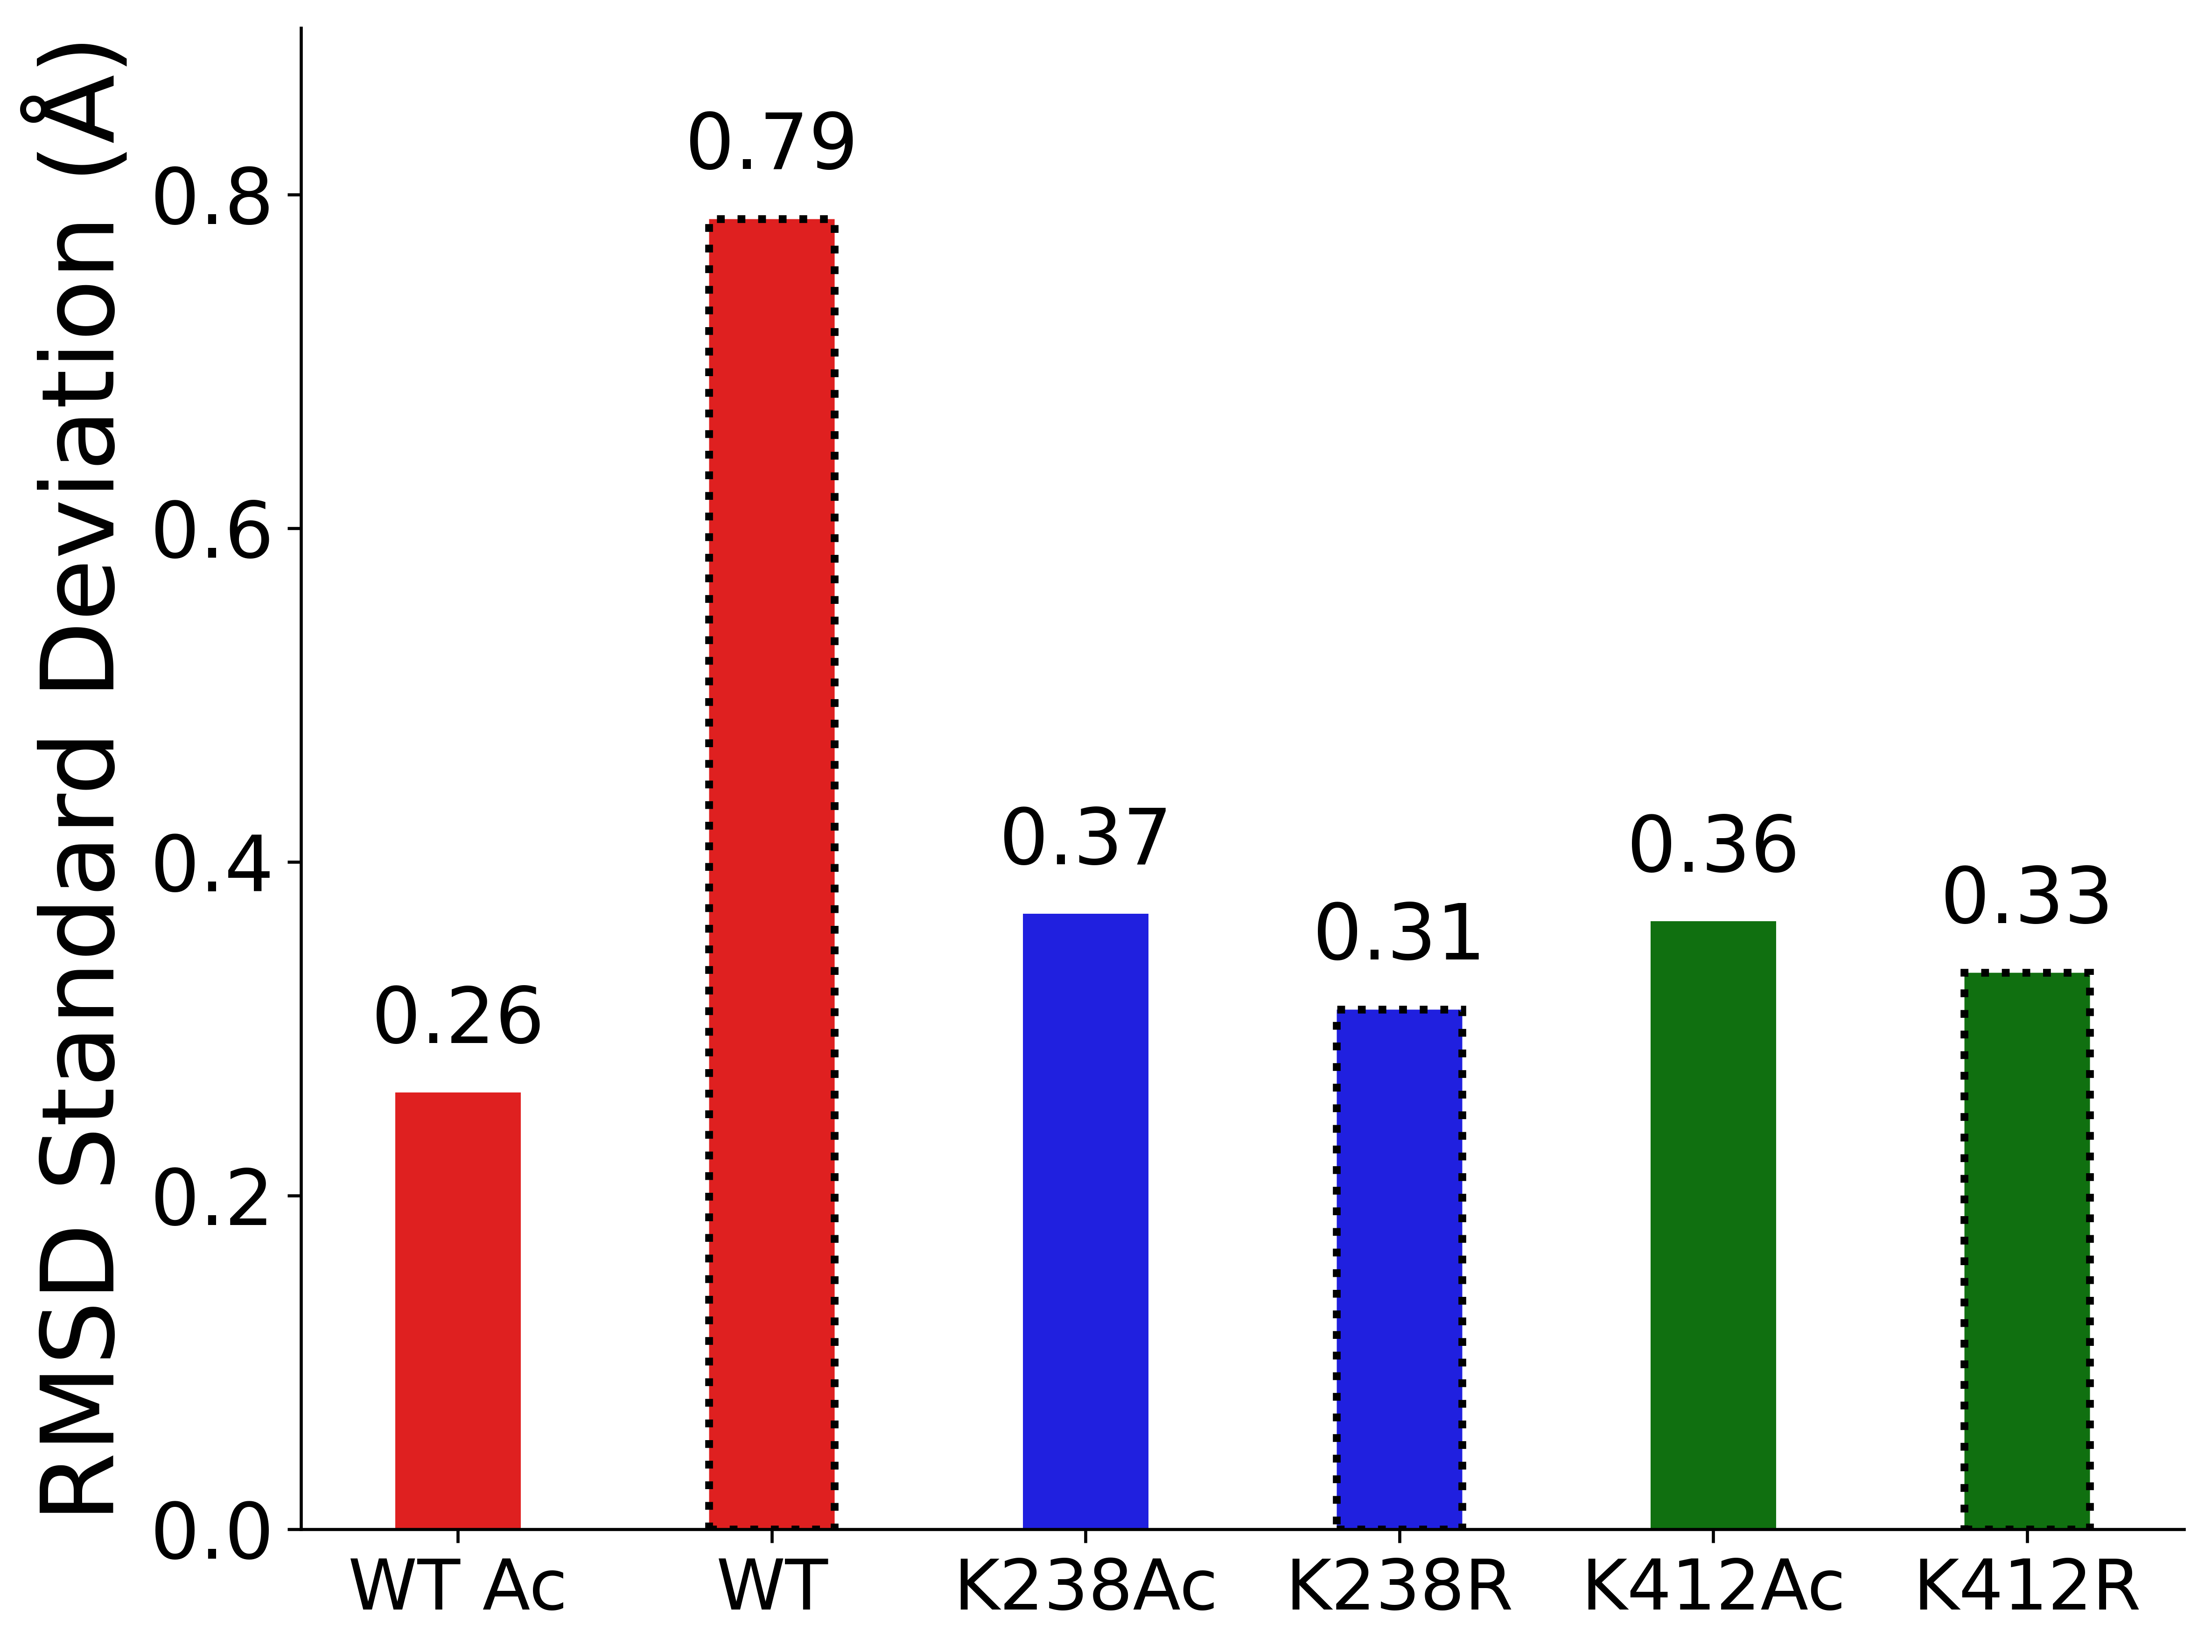

In [61]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

colors = {
    "WT Ac": "red", "K238Ac": "blue", "K412Ac": "green", "WT": "red",
     "K238R": "blue", "K412R": "green"
}

edge_styles = {
    "WT": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},
    "K238R": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},
    "K412R": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},

}

sns.barplot(data=df_avg_amp,
            x='Variant', y='AvgAmplitude_per_ns',
            palette=[colors[v] for v in df_avg_amp['Variant']],
            width=0.4, ax=ax)

for i, v in enumerate(df_avg_amp['AvgAmplitude_per_ns']):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=20)

for i, variant in enumerate(df_avg_amp['Variant']):
    if variant in edge_styles:
        ax.patches[i].set_edgecolor(edge_styles[variant]['color'])
        ax.patches[i].set_linewidth(edge_styles[variant]['linewidth'])
        ax.patches[i].set_linestyle(edge_styles[variant]['linestyle'])

ax.set_xlabel('')
ax.set_ylabel('RMSD Standard Deviation (Å)', fontsize=26)
ax.set_ylim(0, 0.90)
ax.tick_params(axis='x', labelsize=18)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.tick_params(axis='y', labelsize=20)

sns.despine(ax=ax)


separator_x_pos = 2.5
#ax.axvline(x=separator_x_pos, color='black', linestyle='-', linewidth=2)

fig.tight_layout()
fig.savefig(figC, dpi=300)
plt.show()

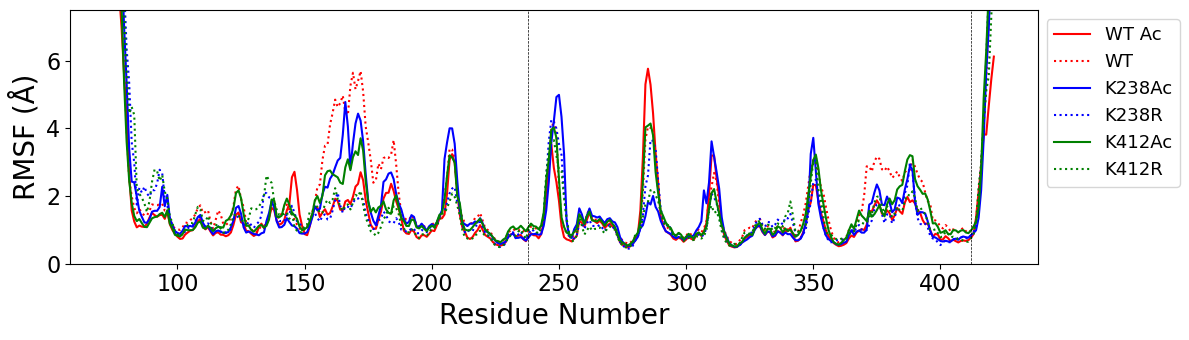

In [75]:
def per_ns_rmsf_xvg(xvg_file):
    """Process RMSF data from XVG, multiplying by 10."""
    data = []
    dest = "Combined_RMSF_plot"
    with open(os.path.join(dest, xvg_file), "r") as f:
        for line in f:
            if line.startswith(("#", "@")):
                continue
            parts = line.strip().split()
            if len(parts) == 2:
                try:
                    t, v = float(parts[0]), float(parts[1])
                    data.append((t, v * 10))
                except ValueError:
                    continue
    df = pd.DataFrame(data, columns=["Time (ns)", "RMSF (Å)"])
    return df


def per_ns_rmsf_csv(csv_file):
    """Process RMSF data from CSV without multiplying values."""
    data = []
    dest = "Combined_RMSF_plot"
    df = pd.read_csv(os.path.join(dest, csv_file))
    df.rename(columns={"Residue Number": "Time (ns)"}, inplace=True)
    return df


wt_rmsf = per_ns_rmsf_xvg("rmsf_500_wt.xvg")
ace238_rmsf = per_ns_rmsf_xvg("rmsf_500_238.xvg")
bothace_rmsf = per_ns_rmsf_xvg("rmsf_500_bothace.xvg")
ace412_rmsf = per_ns_rmsf_xvg("rmsf_500_412ace.xvg")

amp_238R_rmsf = per_ns_rmsf_csv("K238R_rmsf-2.csv")
amp_412R_rmsf = per_ns_rmsf_csv("K412R_rmsf-2.csv")


plt.figure(figsize=(12, 3.5))


plt.plot(bothace_rmsf["Time (ns)"], bothace_rmsf["RMSF (Å)"], label="WT Ac", color="red", linestyle="-")
plt.plot(wt_rmsf["Time (ns)"], wt_rmsf["RMSF (Å)"], label="WT", color="red", linestyle=":")

plt.plot(ace238_rmsf["Time (ns)"], ace238_rmsf["RMSF (Å)"], label="K238Ac", color="blue", linestyle="-")
plt.plot(amp_238R_rmsf["Time (ns)"], amp_238R_rmsf["Value (Å)"], label="K238R", color="blue", linestyle=":")
plt.plot(ace412_rmsf["Time (ns)"], ace412_rmsf["RMSF (Å)"], label="K412Ac", color="green", linestyle="-")
plt.plot(amp_412R_rmsf["Time (ns)"], amp_412R_rmsf["Value (Å)"], label="K412R", color="green", linestyle=":")


plt.axvline(238, ymin=0, ymax=1, ls="--", color="black", linewidth=0.5)
plt.axvline(412, ymin=0, ymax=1, ls="--", color="black", linewidth=0.5)


plt.xlabel("Residue Number", fontsize=20)
plt.ylabel("RMSF (Å)", fontsize=20)


plt.xticks([100, 150, 200, 250, 300, 350, 400], fontsize=16)
plt.yticks([0, 2, 4, 6, 8], fontsize=16)

plt.ylim(0, 7.5)


plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=13)


plt.tight_layout()


plt.savefig(figD, dpi=300, transparent=True)
plt.show()

/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/1328264327.py:42: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(StringIO(data_str), delim_whitespace=True, header=None)
/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/1328264327.py:42: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(StringIO(data_str), delim_whitespace=True, header=None)
/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/1328264327.py:42: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(StringIO(data_str), delim_whitespace=True, header=None)
/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/1328264327.py:42: FutureWarni

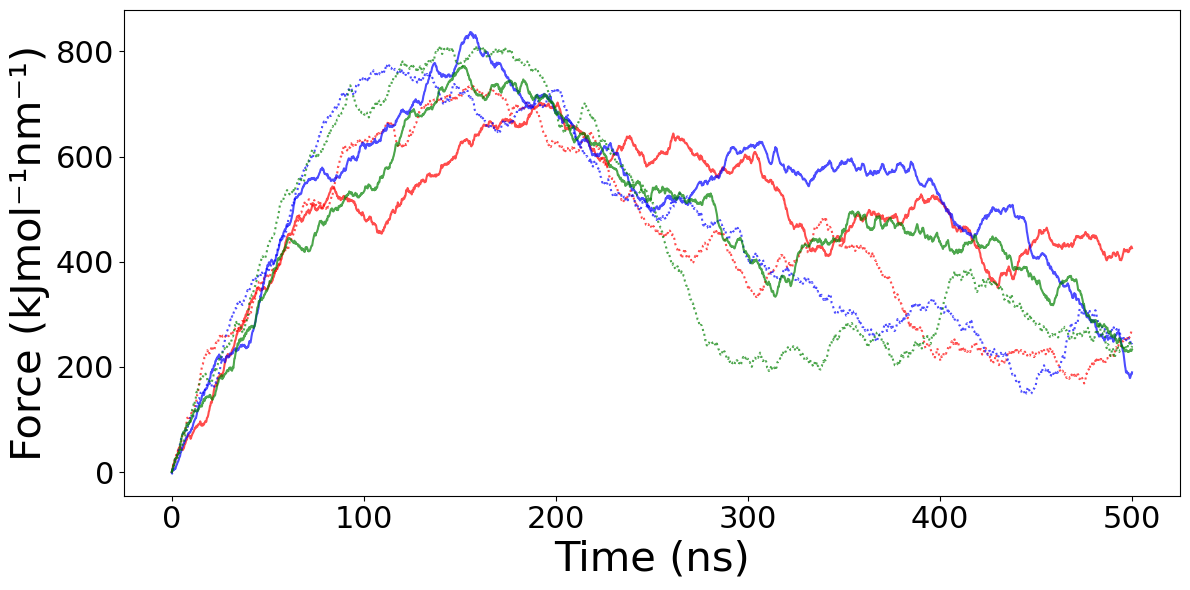

WT Ac - Peak Force: 702.93 kJ/mol/nm at 200.90 ps
WT - Peak Force: 734.16 kJ/mol/nm at 155.30 ps
K238Ac - Peak Force: 836.89 kJ/mol/nm at 155.40 ps
K238R - Peak Force: 774.71 kJ/mol/nm at 112.30 ps
K412Ac - Peak Force: 772.02 kJ/mol/nm at 152.50 ps
K412R - Peak Force: 809.76 kJ/mol/nm at 158.80 ps


In [97]:
from io import StringIO

file_paths = {
    "WT Ac": os.path.join("Pulling_Force_plot", "both_ace_2.xvg"),
    "WT": os.path.join("Pulling_Force_plot", "wt_3.xvg"),
                       
    "K238Ac": os.path.join("Pulling_Force_plot", "238ace_1.xvg"),
    "K238R": os.path.join("Pulling_Force_plot", "K238R_pullf.xvg"),
    
    "K412Ac": os.path.join("Pulling_Force_plot", "412ace_2.xvg"),
    "K412R": os.path.join("Pulling_Force_plot", "K412R_pullf-R2.xvg")
}

colors = {
    "WT Ac": "red",
    "K238Ac": "blue",
    "K412Ac": "green",
    "WT": "red",
    "K238R": "blue",
    "K412R": "green"
}

linestyles = {
    "WT Ac": "-",
    "K238Ac": "-",
    "K412Ac": "-",
    "WT": ":",
    "K238R": ":",
    "K412R": ":"
}

plt.figure(figsize=(12, 6))

peak_forces = {}

for label, file_path in file_paths.items():
    with open(file_path, 'r') as file:
        lines = file.readlines()

    data_lines = [line for line in lines if not line.startswith(('#', '@'))]
    data_str = ''.join(data_lines)
    data = pd.read_csv(StringIO(data_str), delim_whitespace=True, header=None)

    time = data[0]
    force = data[1]

    peak_force = force.max()
    peak_time = time[force.idxmax()]
    peak_forces[label] = (peak_force, peak_time)

    plt.plot(time, force, label=f'{label}', color=colors[label], linestyle=linestyles[label], alpha=0.7)


plt.xlabel('Time (ns)', fontsize=30)
plt.ylabel('Force (kJmol⁻¹nm⁻¹)', fontsize=30)

#plt.legend(fontsize=12)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.tight_layout()

plt.savefig(figE, dpi=300, transparent=True)
plt.show()

for label, (peak_force, peak_time) in peak_forces.items():
    print(f"{label} - Peak Force: {peak_force:.2f} kJ/mol/nm at {peak_time:.2f} ps")

/var/folders/_7/3mxnxnq53wv0cfzj6j23ng240000gn/T/ipykernel_62920/3094344980.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Variant', y='PeakForce',


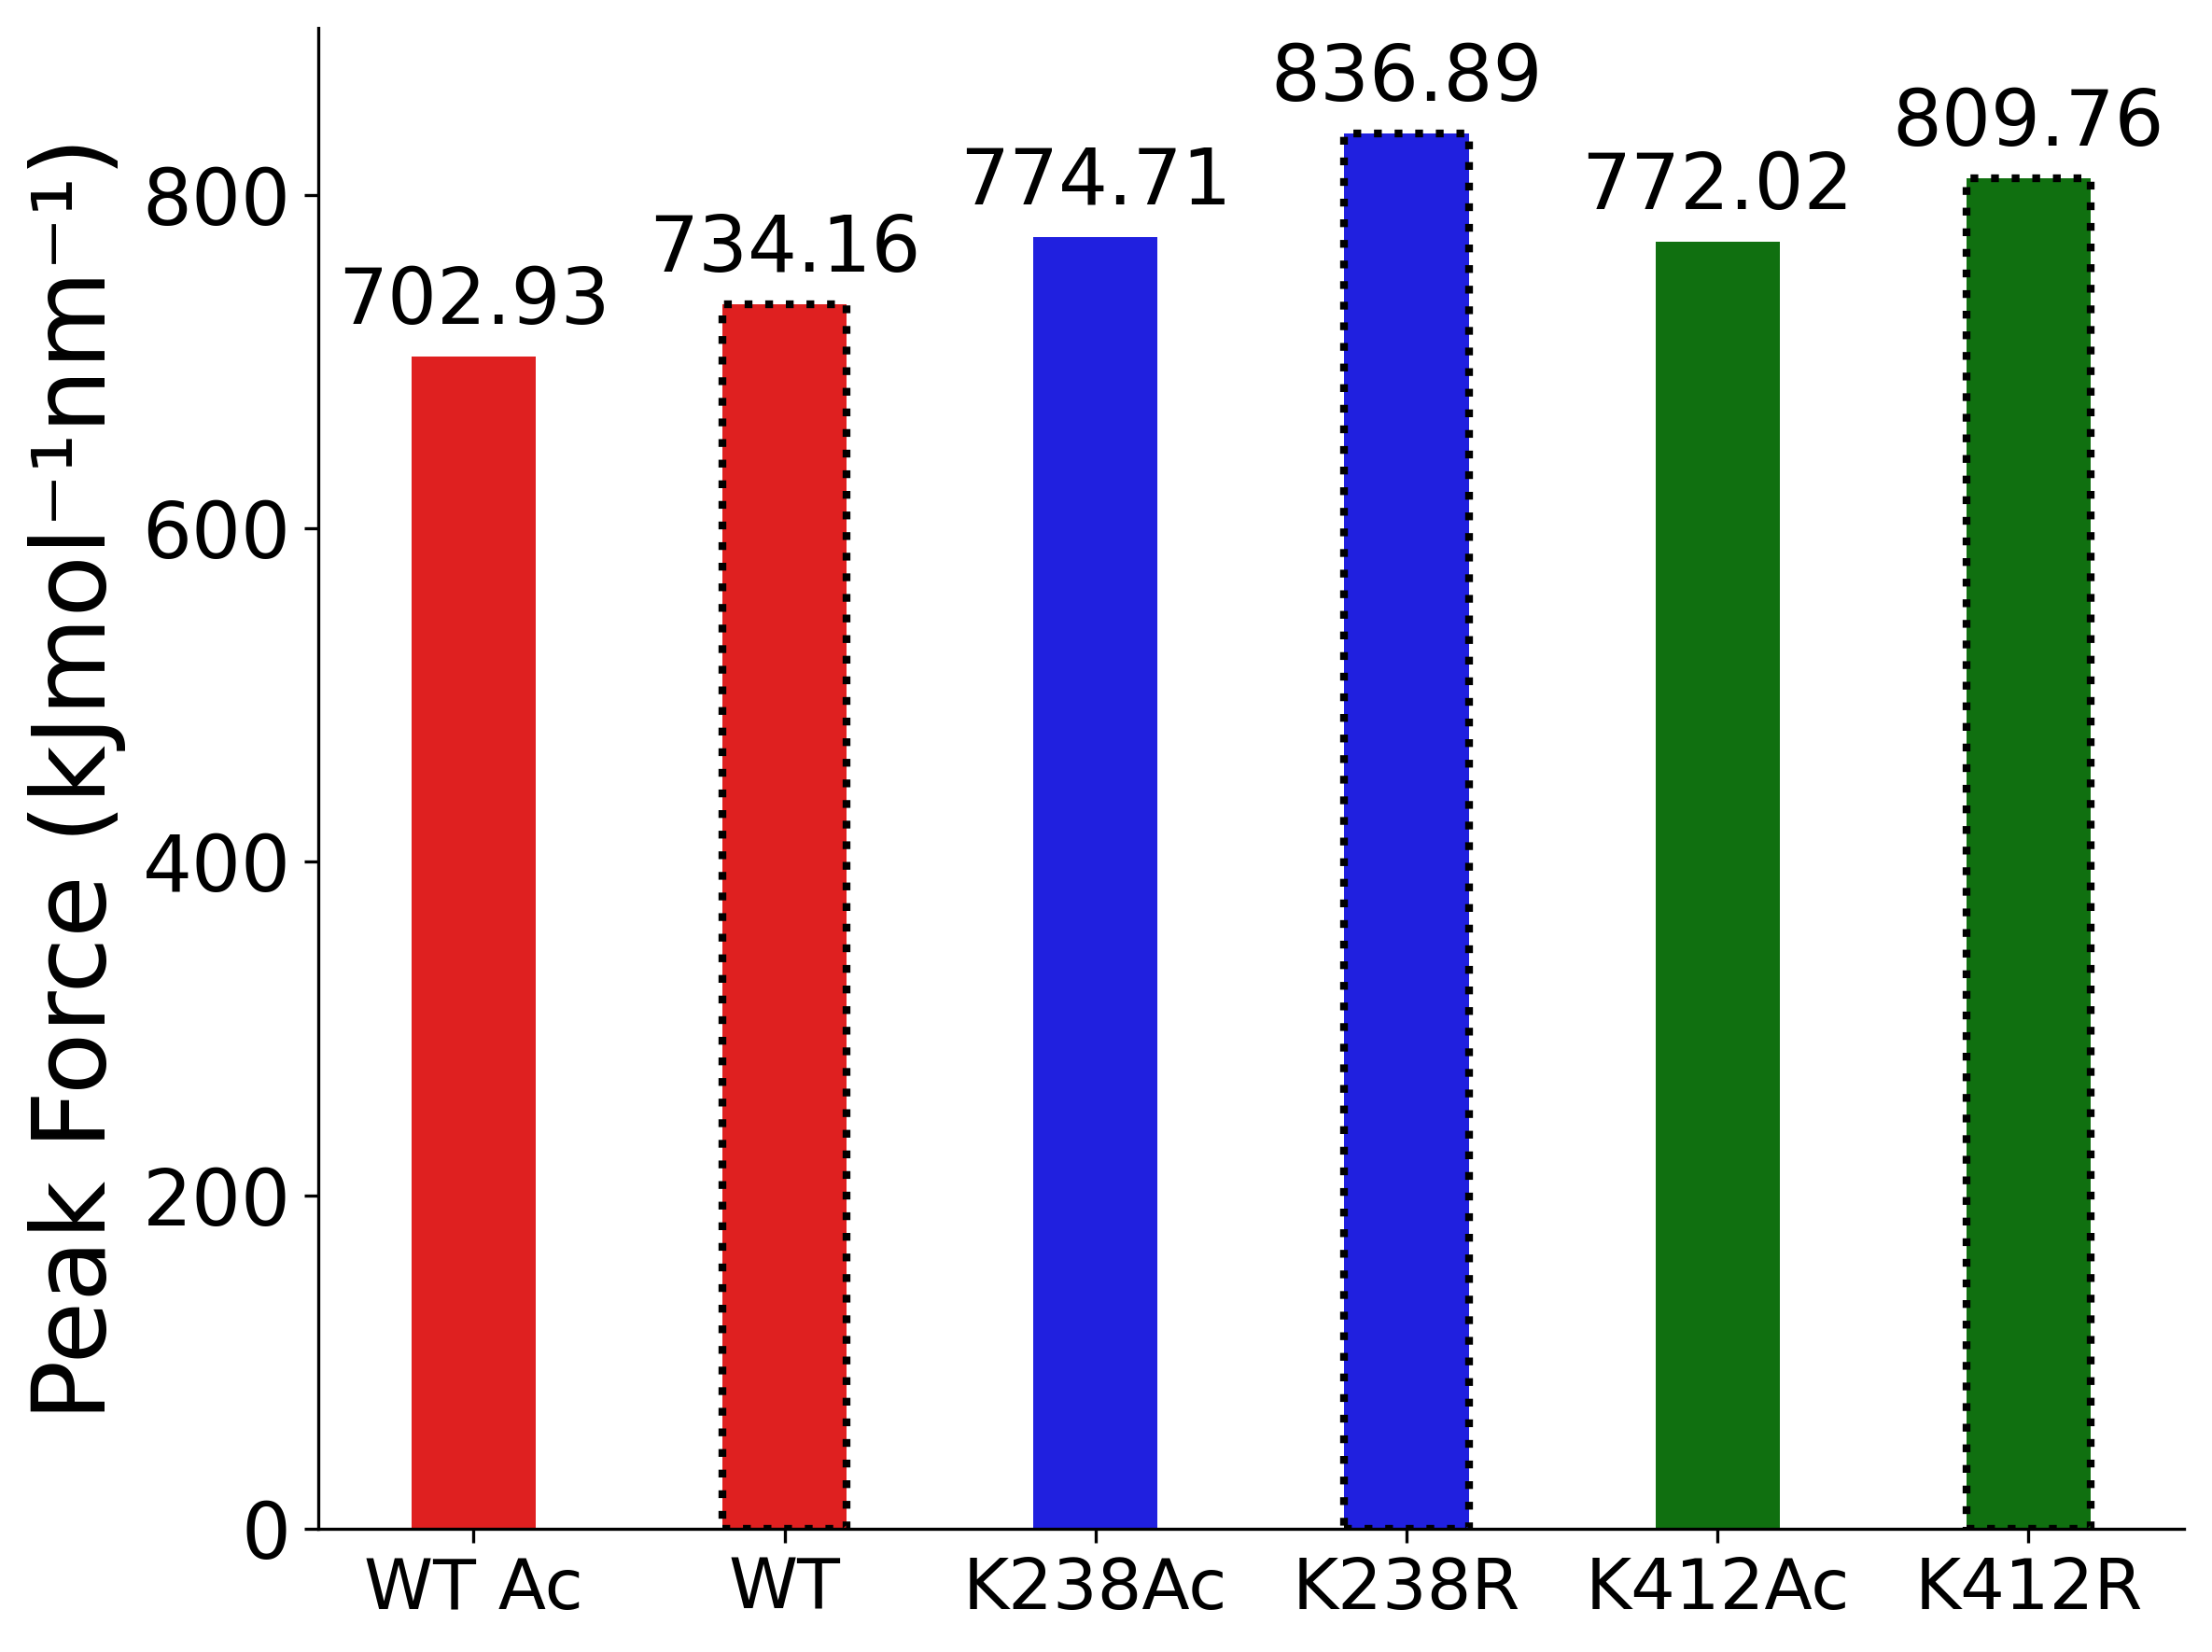

In [79]:
order  = [ 'WT Ac', 'WT', 'K238Ac', 'K238R', 'K412Ac', 'K412R']
colors = {
    'WT Ac': 'red',
    'K238Ac': 'blue',
    'K412Ac': 'green',
    'WT': 'red',
    'K238R': 'blue',
    'K412R': 'green'
}

data = (pd.DataFrame({
                'Variant': ['WT Ac', 'WT', 'K238Ac', 'K238R', 'K412Ac', 'K412R'],
                'PeakForce': [702.93, 734.16, 774.71, 836.89, 772.02, 809.76]})
          .set_index('Variant')
          .loc[order]
          .reset_index())

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.barplot(data=data, x='Variant', y='PeakForce',
            order=order,
            palette=[colors[v] for v in order],
            width=0.4, ax=ax)

edge_styles = {
    "K238R": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},
    "K412R": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},
    "WT": {'color': 'black', 'linewidth': 2, 'linestyle': ':'},
}

for i, variant in enumerate(data['Variant']):
    if variant in edge_styles:
        ax.patches[i].set_edgecolor(edge_styles[variant]['color'])
        ax.patches[i].set_linewidth(edge_styles[variant]['linewidth'])
        ax.patches[i].set_linestyle(edge_styles[variant]['linestyle'])

for i, v in enumerate(data['PeakForce']):
    ax.text(i, v + 10, f'{v:.2f}', ha='center', va='bottom', fontsize=20)

ax.set_xlabel('')
ax.set_ylabel('Peak Force (kJmol⁻¹nm⁻¹)', fontsize=26)
ax.set_ylim(0, 900)
ax.set_yticks([0, 200, 400, 600, 800])
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=20)

sns.despine(ax=ax)


separator_x_pos = 2.5
#ax.axvline(x=separator_x_pos, color='black', linestyle='-', linewidth=2)


fig.tight_layout()

fig.savefig(figF, dpi=300, bbox_inches='tight')

plt.show()

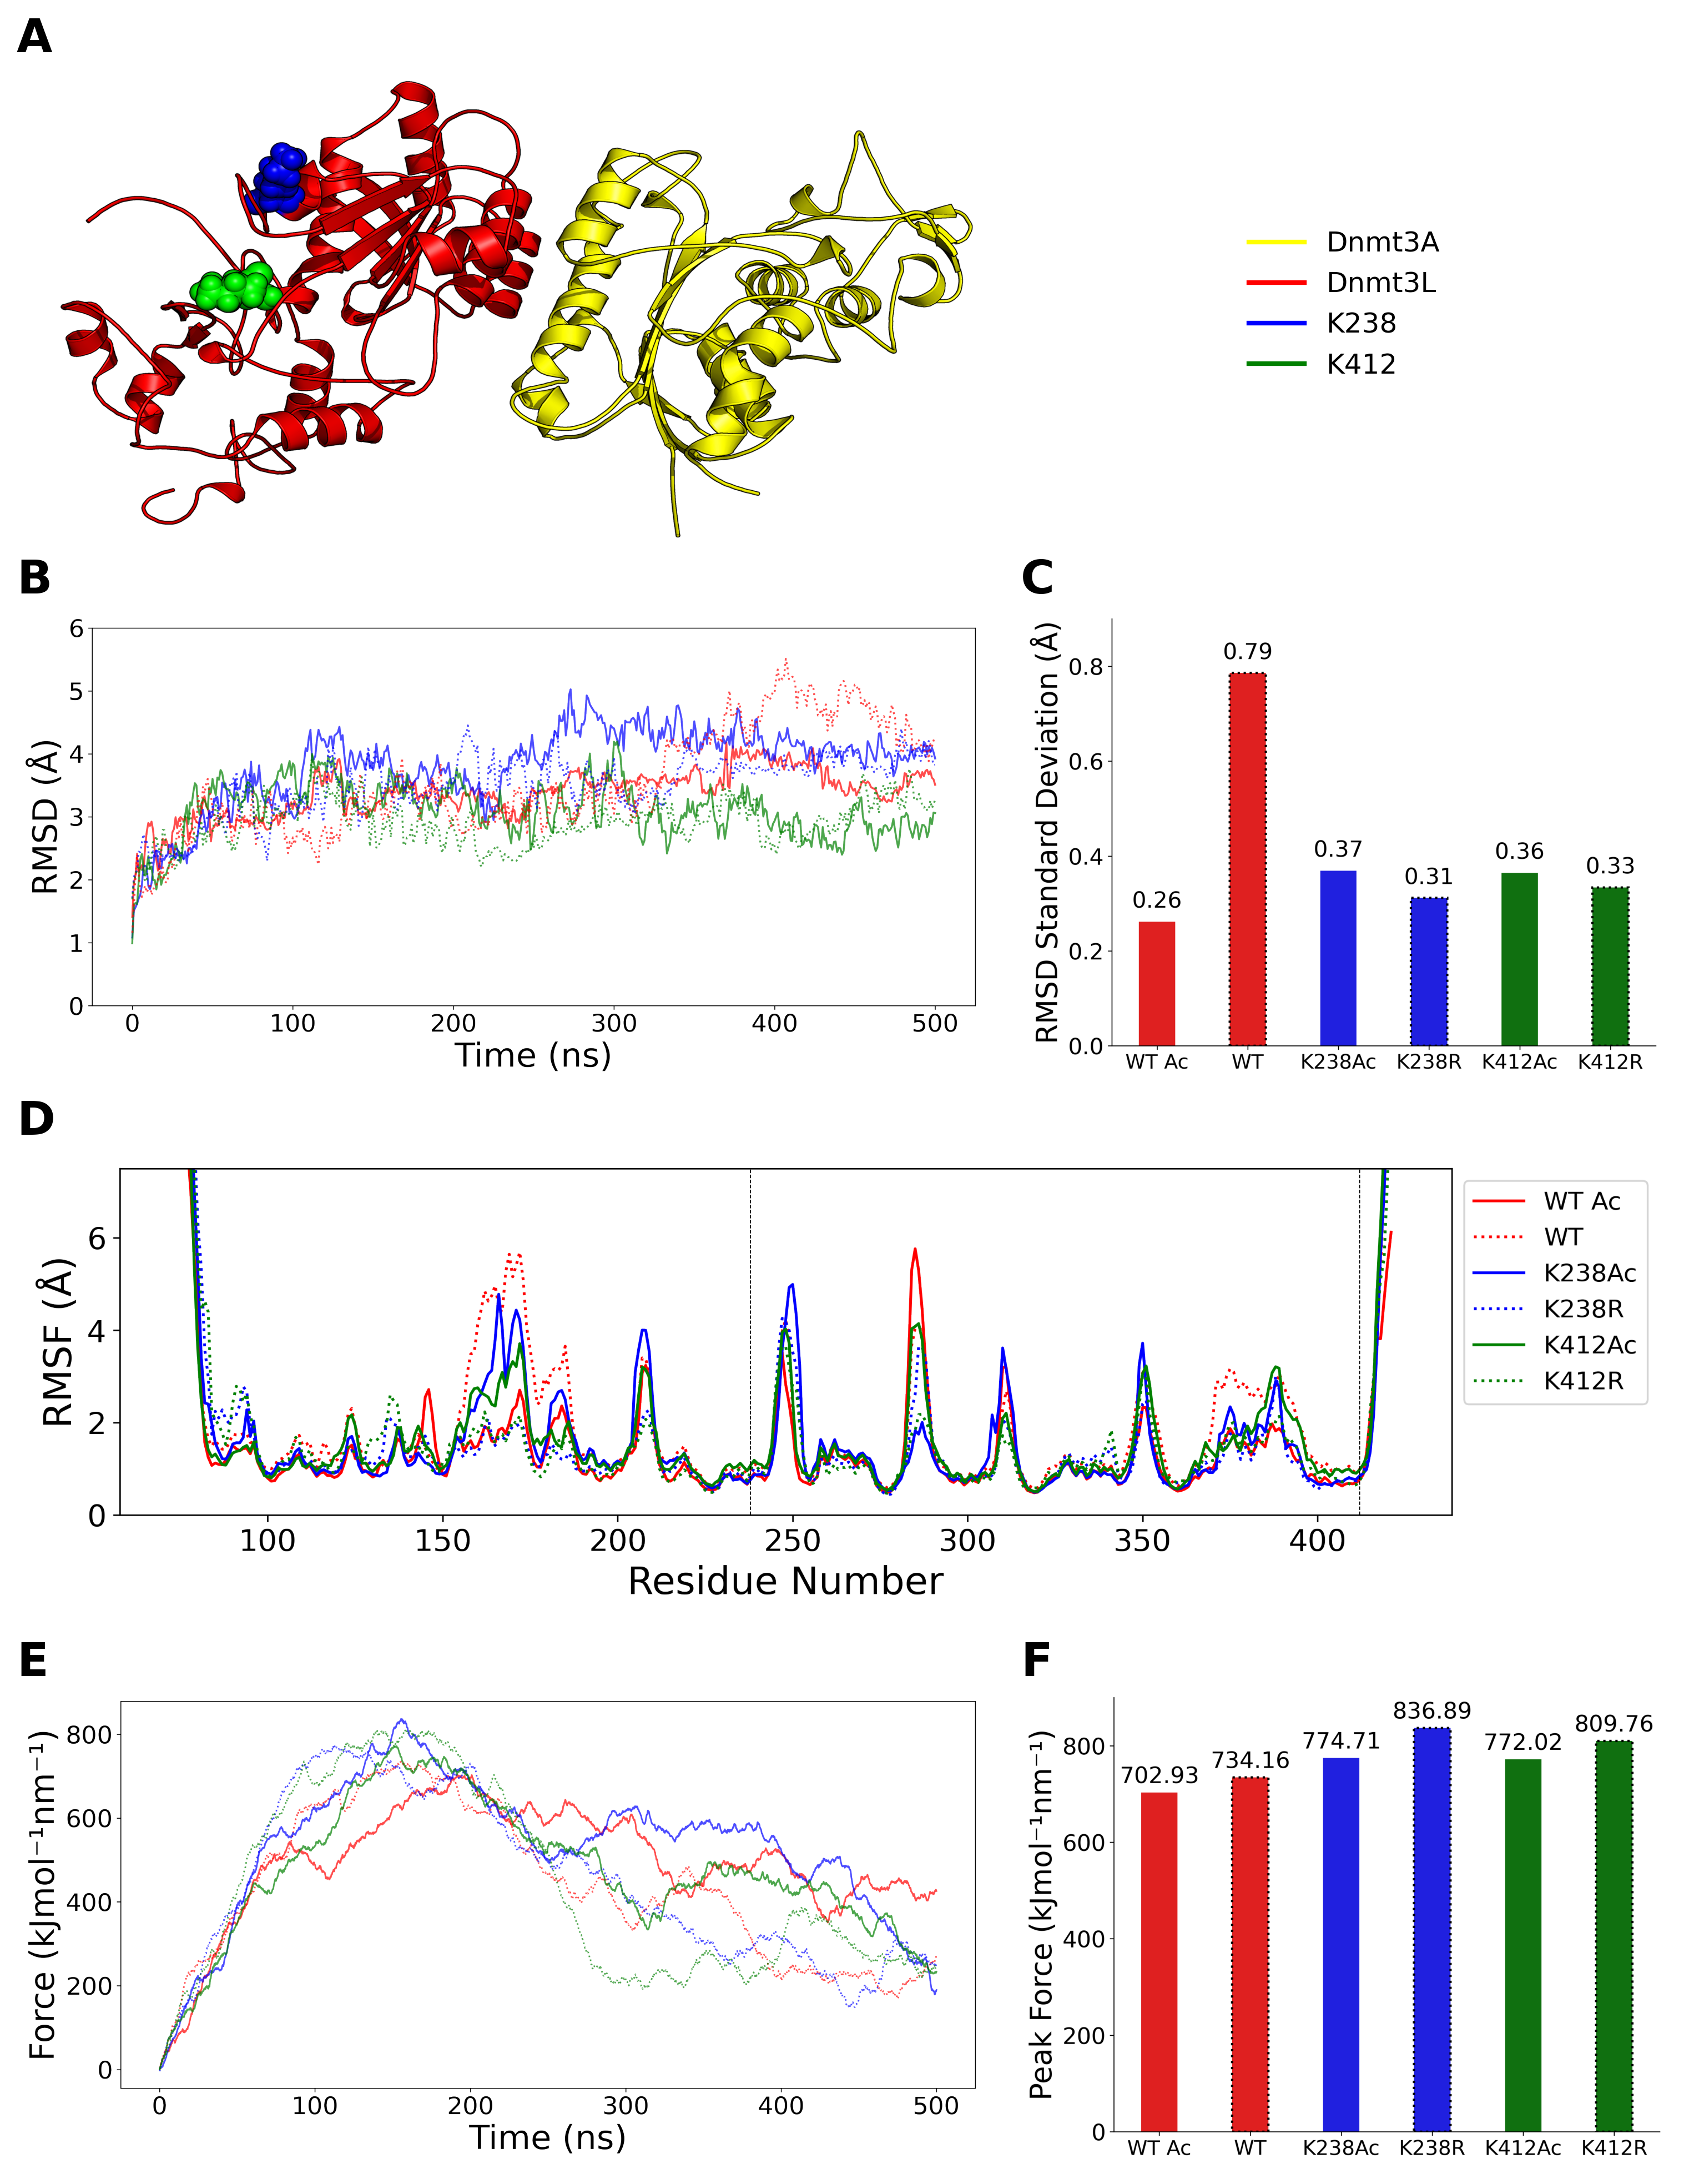

In [109]:
from PIL import Image

files = {
    "A": figA,
    "B": figB,
    "C": figC,
    "D": figD,
    "E": figE,
    "F": figF
}
imgs = {k: Image.open(v) for k, v in files.items()}


fig = plt.figure(figsize=(10, 13), dpi=300, constrained_layout=True)

# Define a gridspec layout with 4 rows and 2 columns
gs  = fig.add_gridspec(
        nrows=4, ncols=2,
        width_ratios=[3, 2],
        height_ratios=[1, 1, 1, 1])

# Create individual axes
axs = {
    'A'  : fig.add_subplot(gs[0, 0]),
    'LEG': fig.add_subplot(gs[0, 1]),
    'B'  : fig.add_subplot(gs[1, 0]),
    'C'  : fig.add_subplot(gs[1, 1]),
    'D'  : fig.add_subplot(gs[2, :]),
    'E'  : fig.add_subplot(gs[3, 0]),
    'F'  : fig.add_subplot(gs[3, 1]),
}

title_map = {
    'A': 'A',
    'B': 'B',
    'C': 'C',
    'D': 'D',
    'E': 'E',
    'F': 'F'
}


for key in ['A', 'B', 'C', 'D', 'E', 'F']:
    ax = axs[key]
    ax.imshow(imgs[key], aspect='auto')
    ax.set_anchor('N')
    ax.set_title(title_map[key], loc='left',
                 fontsize=20, fontweight='bold')
    ax.axis('off')


legend_handles = [
    Line2D([0], [0], color='yellow', lw=2, label='Dnmt3A'),
    Line2D([0], [0], color='red',    lw=2, label='Dnmt3L'),
    Line2D([0], [0], color='blue',   lw=2, label='K238'),
    Line2D([0], [0], color='green',  lw=2, label='K412'),
]

axs['LEG'].legend(handles=legend_handles,
                  loc='center',
                  frameon=False,
                  fontsize=12)
axs['LEG'].axis('off')

fig.savefig('Fig3.png', dpi=300, bbox_inches='tight')
plt.show()